# 08 — Blend v2 (with Re-tuned XGBoost)

Replaces the original XGBoost OOF with the v2 (notebook 07) OOF, then re-runs the SLSQP weight optimisation.

Outputs:
- `outputs/submission_blend_v2.csv` ← byte-safe, integer predictions, Kaggle-ready
- `outputs/blend_v2_weights.json`

In [44]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

OUT_DIR = Path('../outputs')
DATA_DIR = Path('../data')

In [52]:
# Load the local training split target, not the full dataset target
try:
    train_local = pd.read_parquet(OUT_DIR / 'train_local.parquet')
    y = train_local['NumReserveDays2016Q3'].astype(float).values
    print(f"Loaded local target vector, shape: {y.shape}")
except:
    # Fallback to CSV if parquet missing
    train_local = pd.read_csv(OUT_DIR / 'all_train_local.csv')
    y = train_local['NumReserveDays2016Q3'].astype(float).values
    print(f"Loaded local target vector from CSV, shape: {y.shape}")

test_ids = pd.read_csv(DATA_DIR / 'PropertyID_test.csv')['PropertyID'].values

# Use the V3 OOF (trained on 80% split) to match y.shape
oof_files = {
    'LinearRegression': 'oof_LinearRegression.npy',
    'RandomForest':     'oof_RandomForest.npy',
    'GradientBoosting': 'oof_GradientBoosting.npy',
    'XGBoost v2':          'oof_XGBoostV2.npy',
    'XGBoost v3':          'oof_XGBoostV3.npy',
    'MLP':              'oof_MLP.npy',
}
sub_files = {
    'LinearRegression': 'submission_baseline_LinearRegression.csv',
    'RandomForest':     'submission_baseline_RandomForest.csv',
    'GradientBoosting': 'submission_baseline_GradientBoosting.csv',
    'XGBoost v2':          'submission_xgboost_v2.csv',
    'XGBoost v3':          'submission_xgboost_v3.csv',
    'MLP':              'submission_mlp.csv',
}

oofs, subs = {}, {}
for name, oof_name in oof_files.items():
    p_oof = OUT_DIR / oof_name
    p_sub = OUT_DIR / sub_files[name]
    if p_oof.exists() and p_sub.exists():
        oof_loaded = np.load(p_oof)
        # Check for shape mismatch and clip
        if oof_loaded.shape[0] != y.shape[0]:
            print(f'{name:<18s} | SHAPE MISMATCH: target {y.shape[0]} != oof {oof_loaded.shape[0]} (Skipping)')
            continue
            
        # submission files come in different formats
        df_sub = pd.read_csv(p_sub)
        
        # Determine ID column name and Prediction column name
        id_col = None
        for col in ['PropertyID_test', 'Property[Q3]_test', 'PropertyID']:
            if col in df_sub.columns:
                id_col = col
                break
        
        pred_col = None
        for col in ['Pred', 'NumReserveDays2016Q3']:
            if col in df_sub.columns:
                pred_col = col
                break
        
        if id_col is None or pred_col is None:
            print(f'{name:<18s} | COLUMN MISSING in {sub_files[name]} (ID:{id_col}, Pred:{pred_col}) (Skipping)')
            continue

        oofs[name] = np.clip(oof_loaded, 0, 92)
        # align order to test_ids
        df_sub = df_sub.rename(columns={id_col: 'match_id', pred_col: 'Pred'})
        df_sub = df_sub.set_index('match_id').loc[test_ids].reset_index()
        subs[name] = df_sub['Pred'].astype(float).values
        mse = mean_squared_error(y, oofs[name])
        print(f'{name:<18s} | OOF MSE = {mse:8.3f}')
    else:
        print(f'{name:<18s} | MISSING ({oof_name} or {sub_files[name]})')

model_names = [m for m in oofs.keys() if m in subs]
print('\nModels in blend:', model_names)

Loaded local target vector, shape: (19497,)
LinearRegression   | OOF MSE =  207.611
RandomForest       | OOF MSE =  194.235
GradientBoosting   | OOF MSE =  245.286
XGBoost v2         | SHAPE MISMATCH: target 19497 != oof 24372 (Skipping)
XGBoost v3         | OOF MSE =  183.135
MLP                | OOF MSE =  217.617

Models in blend: ['LinearRegression', 'RandomForest', 'GradientBoosting', 'XGBoost v3', 'MLP']


In [54]:
oof_mat  = np.column_stack([oofs[m] for m in model_names])
test_mat = np.column_stack([subs[m] for m in model_names])
print('oof_mat:', oof_mat.shape, '| test_mat:', test_mat.shape)

# Equal-weight baseline
blend_eq = np.clip(oof_mat.mean(axis=1), 0, 92)
print(f'Equal-weight blend OOF MSE = {mean_squared_error(y, blend_eq):.3f}')

oof_mat: (19497, 5) | test_mat: (24318, 5)
Equal-weight blend OOF MSE = 186.929


In [53]:
def blend_mse(w, M, y):
    return float(mean_squared_error(y, np.clip(M @ w, 0, 92)))

k = oof_mat.shape[1]
w0 = np.full(k, 1.0 / k)
res = minimize(blend_mse, w0, args=(oof_mat, y),
               method='SLSQP', bounds=[(0.0, 1.0)] * k,
               constraints=[{'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}],
               options={'maxiter': 500, 'ftol': 1e-9})
w = res.x; w[w < 1e-4] = 0.0; w = w / w.sum()
print('Optimal weights:')
for m, wi in zip(model_names, w):
    print(f'  {m:<18s} = {wi:.4f}')
print(f'\nOptimal blend OOF MSE = {blend_mse(w, oof_mat, y):.3f}')

with open(OUT_DIR / 'blend_v2_weights.json', 'w') as f:
    json.dump({m: float(wi) for m, wi in zip(model_names, w)}, f, indent=2)

Optimal weights:
  LinearRegression   = 0.0791
  RandomForest       = 0.0080
  GradientBoosting   = 0.0000
  XGBoost v3         = 0.7480
  MLP                = 0.1650

Optimal blend OOF MSE = 181.312


In [55]:
# Build final test prediction and write byte-safe CSV
final = np.clip(test_mat @ w, 0, 92)
final_int = np.clip(np.round(final), 0, 92).astype(int)

lines = [b'PropertyID_test,Pred\n']
for i, p in zip(test_ids, final_int):
    lines.append(f'{int(i)},{int(p)}\n'.encode('ascii'))
(OUT_DIR / 'submission_blend_v2.csv').write_bytes(b''.join(lines))

chk = pd.read_csv(OUT_DIR / 'submission_blend_v2.csv')
print(f'Wrote submission_blend_v2.csv | rows={len(chk)} NaN={chk.isna().sum().sum()} '
      f'header={list(chk.columns)} dtype={chk["Pred"].dtype}')
chk.head()

Wrote submission_blend_v2.csv | rows=24318 NaN=0 header=['PropertyID_test', 'Pred'] dtype=int64


,PropertyID_test,Pred
0,795,1
1,2515,54
2,2595,8
3,5099,40
4,5107,29


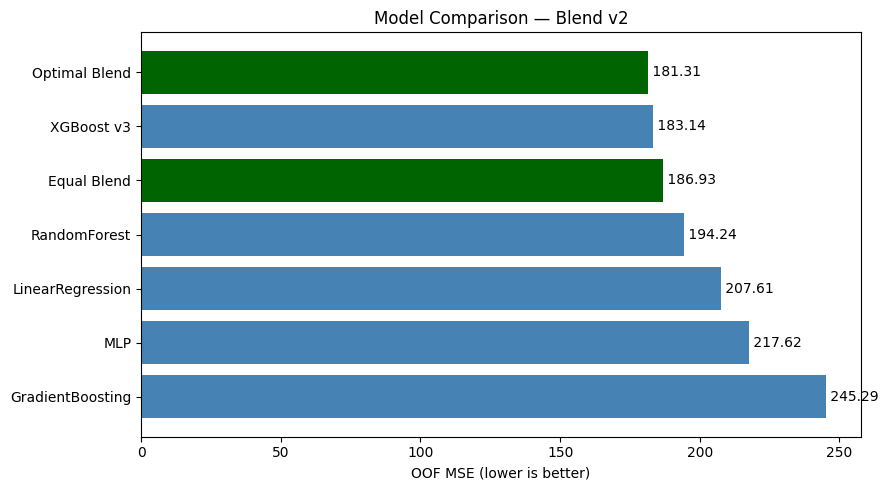

In [56]:
# Comparison plot
scores = {m: mean_squared_error(y, oofs[m]) for m in model_names}
scores['Equal Blend']   = mean_squared_error(y, blend_eq)
scores['Optimal Blend'] = blend_mse(w, oof_mat, y)
s = pd.Series(scores).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['darkgreen' if 'Blend' in n else 'steelblue' for n in s.index]
ax.barh(s.index, s.values, color=colors)
for i, v in enumerate(s.values):
    ax.text(v, i, f' {v:.2f}', va='center')
ax.invert_yaxis()
ax.set_xlabel('OOF MSE (lower is better)')
ax.set_title('Model Comparison — Blend v2')
plt.tight_layout(); plt.savefig(OUT_DIR / 'blend_v2_comparison.png', dpi=120); plt.show()